<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/AVCAD-EXERCISE/blob/main/Exercise9_Ordination_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [40]:
# Load dataset

df = pd.read_csv(
    "EFIplus_medit.csv",
    sep=';'
)

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [41]:
# Show all column names

print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [42]:
# Search for catchment columns

[col for col in df.columns if 'catch' in col.lower()]

['Catchment_name',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'Barriers_catchment_down']

In [43]:
# Check unique catchment names

df['Catchment_name'].unique()

array(['Guadalquivir', 'Tejo', 'Douro', 'Segura', 'Jucar', 'Ebro',
       'Cantabrica', 'Guadia', 'Jucar-Ebro', 'Sur', 'Galiza-Norte',
       'Minho', 'Galiza-Sul', 'Catala', 'Segura-Jucar', 'Garonne',
       'Rhone', 'South_France_E', 'South_France_W', 'Corse',
       'Ombrone-Tevere', 'Campania-South', 'Tevere', 'Arno-Ombrone',
       'Italia-Veneto', 'Sardinia', 'Ombrone', 'Saline-Pescara-Sangro',
       'Oeste', 'Mira', 'Mondego', 'Odelouca', 'Algarve-Sotavento',
       'Algarve-barlavento', 'Sado', 'Tejo-Sado', 'Vouga',
       'EntreDouroeVouga', 'Vouga-Mondego'], dtype=object)

In [44]:
# Filter selected catchments

filtered_df = df[
    df['Catchment_name'].isin(
        [
            'Douro',
            'Tejo',
            'Mondego',
            'Minho'
        ]
    )
]

filtered_df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [45]:
# Check dataframe size

print(filtered_df.shape)

(1703, 164)


In [46]:
# Environmental variables

env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

env_data = filtered_df[
    env_vars
].apply(
    pd.to_numeric,
    errors='coerce'
)

env_data.head()

,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
1,1253,13.406,1603.519424,640.327779,9.3,0.6,18.9
2,1155,9.398,1578.678579,633.238847,10.1,1.2,19.6
3,1074,8.186,1553.219128,625.841858,10.1,1.2,19.5
4,1018,11.736,1539.684999,622.111415,10.3,1.7,20.0
5,979,2.670,1493.914010,608.146170,10.6,1.8,20.2


In [47]:
# Remove missing values

env_data = env_data.dropna()

print(env_data.shape)

(1681, 7)


In [48]:
# Standardize variables

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    env_data
)

scaled_data[:5]

array([[ 2.1257665 , -0.07460296,  1.80135726, -1.08262747, -1.6547649 ,
        -1.93084724, -0.76604362],
       [ 1.83239263, -0.27587255,  1.73857995, -1.10777534, -1.2872155 ,
        -1.69761939, -0.46102077],
       [ 1.58991015, -0.33673551,  1.67423931, -1.13401603, -1.2872155 ,
        -1.69761939, -0.50459546],
       [ 1.42226793, -0.15846529,  1.64003611, -1.14724972, -1.19532815,
        -1.50326285, -0.286722  ],
       [ 1.30551711, -0.61373228,  1.52436454, -1.19679119, -1.05749712,
        -1.46439154, -0.19957261]])

In [49]:
# PCA model

pca = PCA(n_components=2)

pca_scores = pca.fit_transform(
    scaled_data
)

print(
    pca.explained_variance_ratio_
)

[0.60994399 0.21480236]


In [50]:
# PCA dataframe

pca_df = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2']
)

pca_df['Catchment_name'] = filtered_df.loc[
    env_data.index,
    'Catchment_name'
].values

pca_df.head()

,PC1,PC2,Catchment_name
0,-3.697719,-1.461768,Tejo
1,-3.108547,-1.600127,Tejo
2,-2.972605,-1.564704,Tejo
3,-2.706707,-1.552367,Tejo
4,-2.399627,-1.731441,Tejo


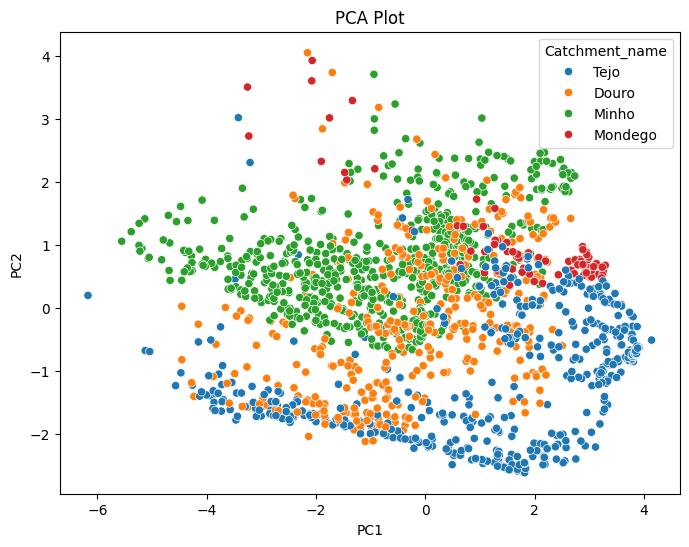

In [51]:
# PCA scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Catchment_name'
)

plt.title("PCA Plot")

plt.show()

# PCA Interpretation

Principal Component Analysis reduced the environmental variables into two principal components.

PC1 explains the greatest amount of variation, while PC2 explains the second greatest amount.

The PCA plot visualizes similarities and differences among catchments.

In [52]:
# PCoA using MDS

mds = MDS(
    n_components=2,
    random_state=42
)

pcoa_scores = mds.fit_transform(
    scaled_data
)

pcoa_scores[:5]

array([[ 2.51645354, -3.12632336],
       [ 2.44986076, -2.54157709],
       [ 2.35910523, -2.42798403],
       [ 2.26046266, -2.16482852],
       [ 2.36353898, -1.8320805 ]])

In [53]:
# PCoA dataframe

pcoa_df = pd.DataFrame(
    pcoa_scores,
    columns=['Axis1', 'Axis2']
)

pcoa_df['Catchment_name'] = filtered_df.loc[
    env_data.index,
    'Catchment_name'
].values

pcoa_df.head()

,Axis1,Axis2,Catchment_name
0,2.516454,-3.126323,Tejo
1,2.449861,-2.541577,Tejo
2,2.359105,-2.427984,Tejo
3,2.260463,-2.164829,Tejo
4,2.363539,-1.832081,Tejo


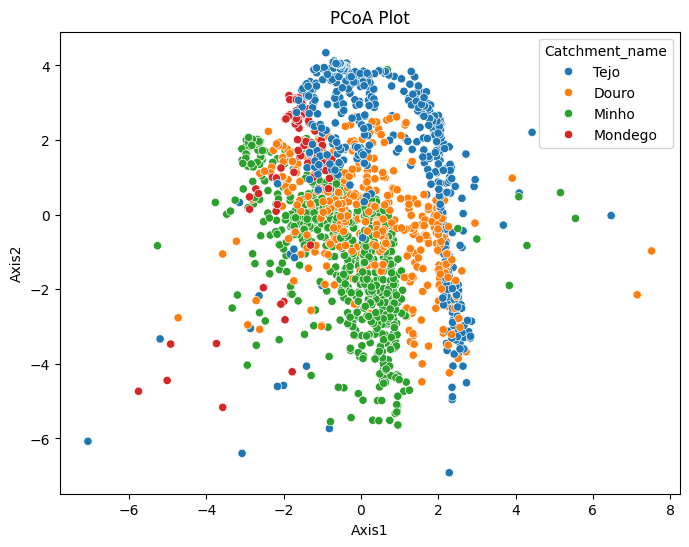

In [54]:
# PCoA scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pcoa_df,
    x='Axis1',
    y='Axis2',
    hue='Catchment_name'
)

plt.title("PCoA Plot")

plt.show()

In [55]:
# Groups

groups = filtered_df.loc[
    env_data.index,
    'Catchment_name'
]

# LDA model

lda = LinearDiscriminantAnalysis(
    n_components=2
)

lda_scores = lda.fit_transform(
    scaled_data,
    groups
)

lda_scores[:5]

array([[0.76090748, 1.28681471],
       [1.25388994, 0.97045572],
       [0.35625968, 1.20909295],
       [0.39762749, 1.01523565],
       [0.44255812, 1.21148167]])

In [56]:
# LDA dataframe

lda_df = pd.DataFrame(
    lda_scores,
    columns=['LD1', 'LD2']
)

lda_df['Catchment_name'] = groups.values

lda_df.head()

,LD1,LD2,Catchment_name
0,0.760907,1.286815,Tejo
1,1.253890,0.970456,Tejo
2,0.356260,1.209093,Tejo
3,0.397627,1.015236,Tejo
4,0.442558,1.211482,Tejo


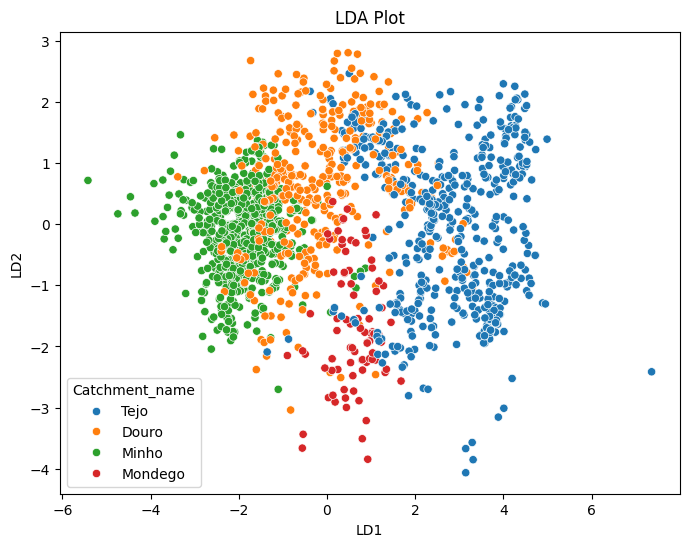

In [57]:
# LDA scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Catchment_name'
)

plt.title("LDA Plot")

plt.show()

# Final Conclusion

This exercise demonstrated:
- Principal Component Analysis (PCA)
- Principal Coordinate Analysis (PCoA)
- Linear Discriminant Analysis (LDA)

These ordination techniques help visualize similarities and differences among environmental observations and catchment groups.